In [6]:
import numpy as np


    Creating a single layer Perceptron

    Parameters:(These are configuration variables (hyperparameters) that are supplied by the 
    user before training begins. They control how the perceptron learns but are not learned 
        from the training data.)
    These the mathematical things like weights, biases which are used in the mathematical equation
    1) eta - learning rate-> a hyperparameter that determines how quickly the perceptron 
        can adjust its weights -> float -> between (0.0,1.0)

    2) n_iter -> number of epochs -> int
        ( 
        -Epochs are basically how many times did the ml model iterate over the dataset
        -It allows the algorithm to process every sample, calculate errors, and 
        update internal weights multiple times.
        -Too many Epochs can lead to overfitting - ie the model has memorized the data set thus
            hurting the real life performance of the model
        -Way too less epochs can lead to underfitting- ie the model failed to learn the patterns
        )
    3) random_state -> setting weights to random values that are very small
        --> Why can we not set the weights and bias to 0 or any constant number:
               1)   In a single layer perceptron it wont matter much 
                    But in a multi layer perceptron if we set all the weights to the same value then
                    the neurons will give similar outputs due to which the different layers of the neural
                    network wont be well used
               2)   It also breaks the symmetry between the neurons thus helps in the ml model
                    learning new featurs 
               3)   It positions the network in a region of weight space where gradients flow,
                    and makes training reproducible when paired with a fixed random seed
    In this we take random_state = 1 (This acts like a seed so that the same random states are generated)
    
    Attributes: ( Attributes are qualities or characteristics that describe an object, individual, or phenomenon)
    These are the object properties 

    1) w_ -> 1d Array
        Weights after fitting
    2) b_ -> Scalar
        Bias Unit after fitting

    errors_ : list 
        Number of misclassifications ( updates ) in each epoch  
        We couldnt use a numpy array here because numpy arrrays are hard to resize
        
    

In [7]:
class Perceptron: 
    def __init__(self, eta = 0.01, n_iter = 50, random_state = 1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self,X,y):
        """
        Parameters : (Input Values)
        X: this is the data set passed in
        {array like}, shape =[n_examples, n_features]
        Training vectors where n_examples is the number of examples and n_features is the 
        number of features 
        Here array-like means it accepts array like data such as numpy arrray , numpy list of lists

        y: This is the correct prediction that should have been made by the perceptron after being trained (basically y^)
         
        """
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc = 0.0, scale = 0.01, size = X.shape[1]) # Draw random samples from a normal (Gaussian) distribution.
        """
        loc -> Mean (Simply the mid point of the data curve)
        scale -> Standard deviation ( How spread out the data is)
            Sets a very small standard deviation. 
            This ensures the random weights stay tiny (mostly between -0.03 and +0.03)
            so the model doesn't start with oversized values.
        size -> How many values do you want the cmoputer to give out and of what  shape 
            Pulls the total number of features (columns) from your data matrix X 
            so each feature gets exactly one weight.
        """

        self.b_ = 0.0  
        self.errors_ = [] 
        # In scikit-learn, the convention is: Attributes ending with _ are created or learned during fit().

        #The learning of the model actually starts
        for _ in range(self.n_iter):
            errors = 0 
            """
            zip(X, y): This functions like a physical zipper. 
            It takes the 1st element of X and pairs it with the 1st element of y into a tuple. 
            Then it does the same for the 2nd elements, the 3rd elements, and so on.
            """

            for xi, target in zip(X,y):
                update = self.eta * (target - self.predict(xi))
                self.w_ += update *xi
                self.b_ += update

                errors += int(update !=0.0)
            self.errors_.append(errors)
        return self

    def net_input(self, X):
        """Returns the net input"""
        ni = np.dot(X,self.w_) + self.b_

        return ni

    def predict(self, X):
        """Returns class label after unit step"""

        return np.where(self.net_input(X) >= 0.0,1,0)
    # if self.net_input(x) >= 0.0, then return 1 else return 0

In [8]:
import os

In [9]:
import pandas as pd

In [10]:
df = pd.read_csv("../../datasets/iris.data", header = None, encoding= 'utf-8') # To read the data 


In [11]:
df.tail()

,0,1,2,3,4
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [12]:
import matplotlib.pyplot as plt

In [13]:
y =df.iloc[0:100, 4].to_numpy()

# extracts the first 100 rows (0-99) and selects the 5th column and converts it into a numpy array using .values and saves it in y 

In [14]:
y = np.where(y == 'Iris-setosa', 0, 1)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [15]:
X = df.iloc[0:100, [0,2]].to_numpy() 
# Gives the petal length and sepal length and convers it into numpy array

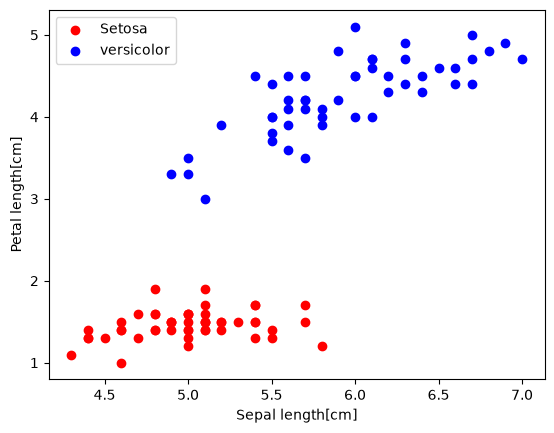

In [16]:
# Plooting the data
plt.scatter(X[:50, 0], X[:50, 1]
            , color = 'red', marker='o', label='Setosa')
plt.scatter(X[50:100, 0], X[50:100, 1]
            , color = 'blue', marker = 'o', label = 'versicolor')
plt.xlabel('Sepal length[cm]')
plt.ylabel('Petal length[cm]')

plt.legend(loc='upper left')

plt.show()

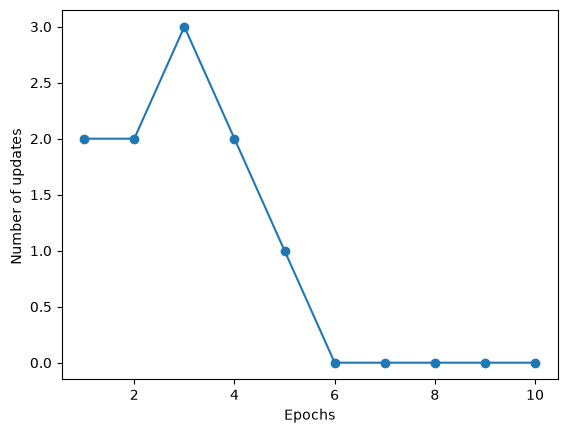

In [17]:
ppn = Perceptron(eta = 0.1, n_iter = 10)
ppn.fit(X, y)
plt.plot(range(1,len(ppn.errors_)+1), ppn.errors_ , marker= 'o' )
plt.xlabel("Epochs")
plt.ylabel("Number of updates ")
plt.show()

In [18]:
#To visualize clear decision boundaries 
from matplotlib.colors import ListedColormap

def plot_decision_regions(X,y,classifier, resolution = 0.02):
    #Setup marker generator and color map

    markers = ('o','s','^','y','<')
    colors = ('red','blue','lightgreen','gray','cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))]) 
    # np.unique(y) -> will get the unique values in the output y in our case it will be 0 and 1 
    # colors[:len(np.unique(y))] -> this will get (2) colors from the colors list we made as only 2 unique values are there in our output y 
    # cmap = ListedColormap(colors[:len(np.unique(y))])  -> this will make the colors into the colormap

    x1_min, x1_max = X[:,0].min() - 1, X[:,0].max() + 1 #Column 0 , all rows -> sepal length
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1 #Column 1 , all rows -> petal length

    xx1, xx2 = np.meshgrid(np.arange(x1_min,x1_max, resolution), np.arange(x2_min, x2_max, resolution))

    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    plt.contourf(xx1,xx2,lab,alpha = 0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x = X[y==cl, 0],
                    y = X[y==cl, 1],
                    alpha = 0.8,
                    c = colors[idx],
                    marker = markers[idx],
                    label=f'Class{cl}',
                    edgecolor = 'black')
    

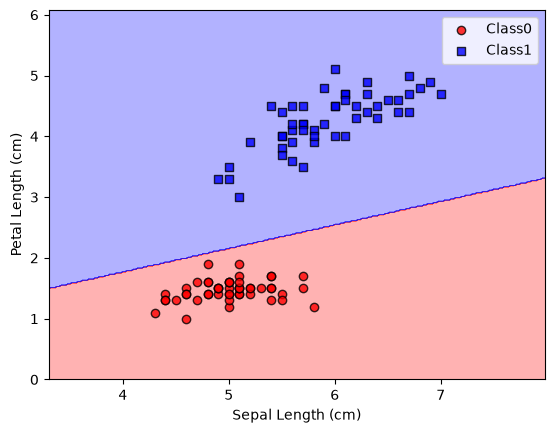

In [19]:
plot_decision_regions(X,y,classifier = ppn)
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")
plt.legend()
plt.show()

In [20]:
from sklearn.tree import DecisionTreeClassifier

In [21]:
tree_model = DecisionTreeClassifier(criterion = 'gini',max_depth = 4, random_state = 1)

In [22]:
tree_model.fit(X_train, y_train)

NameError: name 'X_train' is not defined